# Set Up

In [ ]:
import sys

assert sys.version_info >= (3, 7)

from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# Simple Linear Regression

In [ ]:
# Generate 1D data

import numpy as np

np.random.seed(42)  # to make this code example reproducible
m = 100  # number of instances
X = 2 * np.random.rand(m,1)  # column vector
y = 4 + 3 * X + np.random.randn(m, 1)  # column vector

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$X$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.show()

# Stochastic Gradient Descent Linear Regression with SkLearn

In [ ]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01, learning_rate='constant',verbose=5)
sgd_reg.fit(X, y.ravel()) # y.ravel() because fit() expects 1D targets



In [ ]:
sgd_reg.intercept_, sgd_reg.coef_

In [ ]:
plt.plot(X, y, "b.")

y_predict = sgd_reg.predict(X)
plt.plot(X,y_predict,"k")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.show()

# Polynomial Regression

Generate dataset

In [ ]:
np.random.seed(42)
m = 100
X = np.linspace(-3,3,m)
y = 0.5 * X ** 2 + X + 2 + np.random.normal(size=m)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.show()

Create Polynomial Features

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X.reshape(-1, 1))

print(X[0],X_poly[0])

In [ ]:
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01, learning_rate='constant',verbose=5)
sgd_reg.fit(X_poly, y.ravel()) # y.ravel() because fit() expects 1D targets

y_predicted_sgd = sgd_reg.predict(X_poly)


plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X, y_predicted_sgd, "g-", linewidth=2, label="Stochastic Gradient Descent")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.title('Stochastic Gradient Descent')
plt.grid()
plt.show()

# Learning rate scheduling
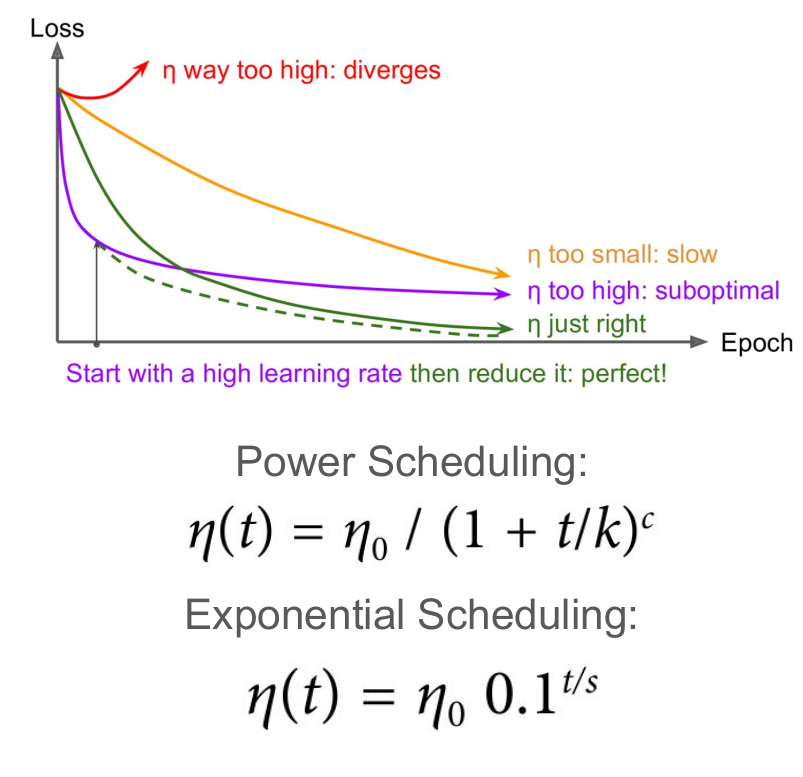

In [ ]:
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.1, learning_rate='invscaling',verbose=5)
sgd_reg.fit(X_poly, y.ravel()) # y.ravel() because fit() expects 1D targets

y_predicted_sgd = sgd_reg.predict(X_poly)


plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X, y_predicted_sgd, "g-", linewidth=2, label="Stochastic Gradient Descent")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.title('Stochastic Gradient Descent')
plt.grid()
plt.show()

# Simplifying implementation with SKLearn Pipeline method

In [ ]:
from sklearn.pipeline import Pipeline
from  sklearn.preprocessing import StandardScaler
#use pipeline to make model
model =  Pipeline([('poly',PolynomialFeatures(degree=2)),
                   ('normalize',StandardScaler()),
                   ('SGD',SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01, learning_rate='constant'))])

model.fit(X_poly, y.ravel())

y_predicted = model.predict(X_poly)


plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X, y_predicted_sgd, "g-", linewidth=2, label="Stochastic Gradient Descent")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.grid()
plt.show()

# Overfitting and Regularization
Let's generate a noisy **Linear dataset** and try to fit it with polynomial function and then perform L2 and L1 resularization.

We will use RidgeRegression function from sklearn for initial unregulaized fitting for consistency.

In [ ]:
np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5


plt.figure(figsize=(6, 4))
plt.plot(X, y, ".")
plt.xlabel("$x_1$")
plt.ylabel("$y$  ", rotation=0)
plt.axis([0, 3, 0, 3.5])
plt.grid()
plt.show()

Fit without regularization ($\alpha$=0)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

#use pipeline to build model
model = Pipeline([('poly',PolynomialFeatures(degree=10, include_bias=False)),
                  ('normalize',StandardScaler()),
                  ('LinearRegression',LinearRegression())])

model.fit(X.reshape(-1,1), y.reshape(-1,1))

#test it on new data
X_new = np.linspace(0, 3, 100).reshape(100, 1)

y_new = model.predict(X_new)
plt.plot(X, y, ".")
plt.plot(X_new, y_new, linewidth=1, color='r')
plt.title('No Regularization')
plt.xlabel("$x_1$")
plt.ylabel("$y$  ", rotation=0)
plt.axis([0, 3, 0, 3.5])
plt.grid()
plt.show()

# L2 Regularization (Ridge Regreesion)

In [ ]:
from sklearn.linear_model import Ridge

from sklearn.pipeline import Pipeline

#use pipeline to build model
model_l2 = Pipeline([('poly',PolynomialFeatures(degree=10, include_bias=False)),
                  ('normalize',StandardScaler()),
                  ('RidgeRegression',Ridge(alpha=0.5))])

model_l2.fit(X.reshape(-1,1), y.reshape(-1,1))

#test it on new data
X_new = np.linspace(0, 3, 100).reshape(100, 1)

y_new_l2 = model_l2.predict(X_new)
plt.plot(X, y, ".")
plt.plot(X_new, y_new, linewidth=1, color='r',label='No Regularization')
plt.plot(X_new, y_new_l2, linewidth=1, color='g',label='L2 Regularization')
plt.title('L2 Regularization')
plt.xlabel("$x_1$")
plt.ylabel("$y$  ", rotation=0)
plt.axis([0, 3, 0, 3.5])
plt.grid()
plt.legend()
plt.show()

# L1 Regularization (Lasso Regreesion)

In [ ]:
from sklearn.linear_model import Lasso

from sklearn.pipeline import Pipeline

#use pipeline to build model
model_l1 = Pipeline([('poly',PolynomialFeatures(degree=10, include_bias=False)),
                  ('normalize',StandardScaler()),
                  ('LassoRegression',Lasso(alpha=0.5))])

model_l1.fit(X.reshape(-1,1), y.reshape(-1,1))

#test it on new data
X_new = np.linspace(0, 3, 100).reshape(100, 1)

y_new_l1 = model_l1.predict(X_new)
plt.plot(X, y, ".")
plt.plot(X_new, y_new, linewidth=1, color='r',label='No Regularization')
plt.plot(X_new, y_new_l1, linewidth=1, color='g',label='L1 Regularization')
plt.title('L1 Regularization')
plt.xlabel("$x_1$")
plt.ylabel("$y$  ", rotation=0)
plt.axis([0, 3, 0, 3.5])
plt.grid()
plt.legend()
plt.show()

# Test on Molecular Solvation Data

In [ ]:
import pandas as pd

df = pd.read_csv('solubility_data.csv')

df.head(10)

In [ ]:
import seaborn as sns

data = X = df[['Molecular Weight','Number of H-Bond Donors','Number of Rings','Number of Rotatable Bonds','Polar Surface Area']]
sns.pairplot(data)

In [ ]:
X = df[['Molecular Weight','Number of H-Bond Donors','Number of Rings','Number of Rotatable Bonds','Polar Surface Area']].to_numpy()
y = df[['measured log solubility in mols per litre']].to_numpy()

Create pipeline for linear regression with stochastic gradient descent

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

#use pipeline to make model
model =  Pipeline([('normalize',StandardScaler()),
                   ('SGD',SGDRegressor(max_iter=1000,
                                       tol=1e-5,
                                       penalty=None,
                                       eta0=0.01,
                                       learning_rate='invscaling'))])
model.fit(X,y)

#plot output
y_predict = model.predict(X)

plt.scatter(y,y_predict,color='r')
plt.plot(y,y)

#calculate r2 score
r2 = r2_score(y,y_predict)
plt.text(-10,0,'R$^2$ = %0.3f'%r2)


plt.xlabel('Target')
plt.ylabel('Prediction')
plt.title('weights = '+str(model['SGD'].coef_)+' bias = '+str(model['SGD'].intercept_),fontsize=10)


**Polynomial regression**

In [ ]:
#use pipeline to make model
model =  Pipeline([('poly',PolynomialFeatures(degree=2,
                                              include_bias=False)),
                    ('normalize',StandardScaler()),
                    ('SGD',SGDRegressor(max_iter=1000,
                                        tol=1e-5,
                                        penalty=None,
                                        eta0=0.01,
                                        learning_rate='constant'))])
model.fit(X,y)

#plot output
y_predict = model.predict(X)

plt.scatter(y,y_predict,color='r')
plt.plot(y,y)

#calculate r2 score
r2 = r2_score(y,y_predict)
plt.text(-10,0,'R$^2$ = %0.3f'%r2)


plt.xlabel('Target')
plt.ylabel('Prediction')

In [ ]:
#exponential scheduling after starting with higher learning rate
model =  Pipeline([('poly',PolynomialFeatures(degree=2, include_bias=False)),
                    ('normalize',StandardScaler()),
                    ('SGD',SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01, learning_rate='invscaling'))])
model.fit(X,y)

#plot output
y_predict = model.predict(X)

plt.scatter(y,y_predict,color='r')
plt.plot(y,y)

#calculate r2 score
r2 = r2_score(y,y_predict)
plt.text(-10,0,'R$^2$ = %0.3f'%r2)


plt.xlabel('Target')
plt.ylabel('Prediction')

In [ ]:
#exponential scheduling after starting with higher learning rate
model =  Pipeline([('poly',PolynomialFeatures(degree=2,
                                              include_bias=False)),
                    ('normalize',StandardScaler()),
                    ('SGD',SGDRegressor(max_iter=1000,
                                        tol=1e-5,
                                        penalty='l2',
                                        alpha=0.1,
                                        eta0=0.01,
                                        learning_rate='invscaling'))])
model.fit(X,y)

#plot output
y_predict = model.predict(X)

plt.scatter(y,y_predict,color='r')
plt.plot(y,y)

#calculate r2 score
r2 = r2_score(y,y_predict)
plt.text(-10,0,'R$^2$ = %0.3f'%r2)


plt.xlabel('Target')
plt.ylabel('Prediction')

print(model['SGD'].coef_)

In [ ]:
#exponential scheduling after starting with higher learning rate
model =  Pipeline([('poly',PolynomialFeatures(degree=2,
                                              include_bias=False)),
                    ('normalize',StandardScaler()),
                    ('SGD',SGDRegressor(max_iter=1000,
                                        tol=1e-5,
                                        penalty='l1',
                                        alpha=0.1,
                                        eta0=0.01,
                                        learning_rate='invscaling'))])
model.fit(X,y)

#plot output
y_predict = model.predict(X)

plt.scatter(y,y_predict,color='r')
plt.plot(y,y)

#calculate r2 score
r2 = r2_score(y,y_predict)
plt.text(-10,0,'R$^2$ = %0.3f'%r2)


plt.xlabel('Target')
plt.ylabel('Prediction')

print(model['SGD'].coef_)

In [ ]:
#exponential scheduling after starting with higher learning rate
model =  Pipeline([('poly',PolynomialFeatures(degree=2,
                                              include_bias=False)),
                    ('normalize',StandardScaler()),
                    ('SGD',SGDRegressor(max_iter=1000,
                                        tol=1e-5,
                                        penalty='elasticnet',
                                        alpha=0.1,
                                        eta0=0.01,
                                        learning_rate='invscaling'))])
model.fit(X,y)

#plot output
y_predict = model.predict(X)

plt.scatter(y,y_predict,color='r')
plt.plot(y,y)

#calculate r2 score
r2 = r2_score(y,y_predict)
plt.text(-10,0,'R$^2$ = %0.3f'%r2)


plt.xlabel('Target')
plt.ylabel('Prediction')

print(model['SGD'].coef_)

# Cross Validation

In [ ]:
from sklearn.linear_model import Lasso

model =  Pipeline([('poly',PolynomialFeatures(degree=2,
                                              include_bias=False)),
                    ('normalize',StandardScaler()),
                    ('Lasso',Lasso(alpha=0.1))])
model.fit(X,y)

#plot output
y_predict = model.predict(X)

plt.scatter(y,y_predict,color='r')
plt.plot(y,y)

#calculate r2 score
r2 = r2_score(y,y_predict)
plt.text(-10,0,'R$^2$ = %0.3f'%r2)


plt.xlabel('Target')
plt.ylabel('Prediction')

print(model['Lasso'].coef_)

In [ ]:
from sklearn.linear_model import LassoCV

model =  Pipeline([('poly',PolynomialFeatures(degree=2,
                                              include_bias=False)),
                    ('normalize',StandardScaler()),
                    ('LassoCV',LassoCV())])
model.fit(X,y)

#plot output
y_predict = model.predict(X)

plt.scatter(y,y_predict,color='r')
plt.plot(y,y)

#calculate r2 score
r2 = r2_score(y,y_predict)
plt.text(-10,0,'R$^2$ = %0.3f'%r2)


plt.xlabel('Target')
plt.ylabel('Prediction')

print(model['LassoCV'].coef_)